In [27]:
from typing import List
import scipy.stats as stats
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

In [ ]:
def load_data(path: str) -> pd.DataFrame:
    return pd.read_json(path)

def metric(data: pd.DataFrame) -> np.ndarray:
    data = data[data['step'] > 0]
    data['miscoverage'] = 1
    lower_ids = data['y_real'] < data['pi_low']
    data.loc[lower_ids, 'miscoverage'] = (data['pi_low'] - data['y_real']).iloc[lower_ids]

    upper_ids = data['y_real'] > data['pi_high']
    data.loc[upper_ids, 'miscoverage'] = (data['y_real'] - data['pi_high']).iloc[upper_ids]

    results = (data['miscoverage'] * (data['pi_high'] - data['pi_low'])).values
    return results

In [ ]:
def agg_metric_values(data_paths: List[List[str]]) -> List[np.ndarray]:
    metrics = []
    for paths in data_paths:
        cur_metrics = []
        for path in paths:
            data = load_data(path)
            cur_metric = metric(data)
            cur_metrics.append(cur_metric)
        metrics.append(np.concatenate(cur_metrics))
    return metrics

In [29]:
def compute_statistics(data: List[np.ndarray]) -> list:
    return [
        stats.wilcoxon(data[0, :], data[i, :]).pvalue for i in range(1, data.shape[1])
    ]


def format_statistics(data: np.ndarray) -> list:
    return [round(datum, 2) for datum in data]

In [ ]:
ALPHA_0_05_PATHS = [
    ["path1", "path2", "path3"] # DIST_MATCH_PATHS,
    ["path1", "path2", "path3"] # HOP_CPT_PATHS,
]
ALPHA_0_10_PATHS = [
    ["path1", "path2", "path3"] # DIST_MATCH_PATHS,
    ["path1", "path2", "path3"] # HOP_CPT_PATHS,
]
ALPHA_0_15_PATHS = [
    ["path1", "path2", "path3"] # DIST_MATCH_PATHS,
    ["path1", "path2", "path3"] # HOP_CPT_PATHS,
]

alpha_0_05 = agg_metric_values(ALPHA_0_05_PATHS)
alpha_0_10 = agg_metric_values(ALPHA_0_10_PATHS)
alpha_0_15 = agg_metric_values(ALPHA_0_15_PATHS)

In [35]:
print("Alpha = 0.05: ",format_statistics(compute_statistics(alpha_0_05)))
print("Alpha = 0.10: ",format_statistics(compute_statistics(alpha_0_10)))
print("Alpha = 0.15: ",format_statistics(compute_statistics(alpha_0_15)))

Alpha = 0.05:  [0.81, 0.81, 0.02, 0.3, 0.16, 0.22]
Alpha = 0.10:  [0.47, 0.38, 0.05, 0.31, 0.05, 0.08]
Alpha = 0.15:  [0.72, 0.38, 0.02, 0.3, 0.03, 0.03]


In [36]:
METHODS = ['HopCPT', 'SPCI', 'EnbPI', 'NexCP', 'CP', 'Copula']

In [78]:
def plot_statistics(data_map: np.ndarray, categories: list):
    n_data = len(data_map)
    fig, axes = plt.subplots(ncols=n_data, figsize=(3 * n_data, 2))
    for idx, (title, data) in enumerate(data_map.items()):
        axes[idx].bar(categories, data)
        axes[idx].axhline(y=0.05, linewidth=2, color="red", ls="--")
        axes[idx].set_title(title)
        if idx != 0:
            axes[idx].set_yticklabels([])
        else:
            axes[idx].set_ylabel('P-value')
    fig.tight_layout()
    return fig

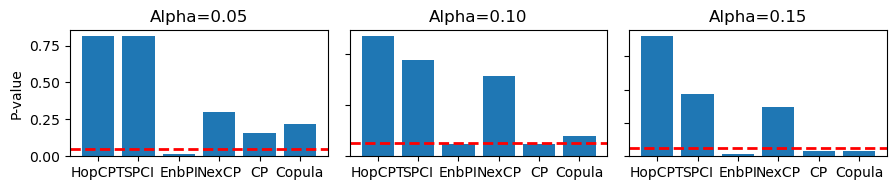

In [80]:
fig = plot_statistics(
    {
        "Alpha=0.05": compute_statistics(alpha_0_05),
        "Alpha=0.10": compute_statistics(alpha_0_10),
        "Alpha=0.15": compute_statistics(alpha_0_15),
    },
    METHODS,
)
fig.savefig('wilcoxon_test.pdf')